In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from useful_functions import *
import pandas as pd
from joblib import Parallel, delayed

In [2]:
dp_df = pd.read_csv('dp_cand_results.csv', low_memory=False)
print(f'All: {len(dp_df)}')
dp_candidates = dp_df[(dp_df['p_value'] < 0.05) & (dp_df['delta_dv'] > 75)]
print(f'DP Candidates: {len(dp_candidates)} ({len(dp_candidates) / len(dp_df) * 100:.2f}%)')

All: 20716
DP Candidates: 20716 (100.00%)


In [3]:
# with open('dp_candidates_ids.txt', 'w+') as f:
#     for tid in dp_candidates['TARGETID'].to_list():
#         f.write(f"{tid}\n")

In [4]:
display(dp_candidates.head(5))

,TARGETID,p_value,dv,delta_dv,sigma,OII3726_dp,OII3729_dp,Hbeta_dp,OIII4959_dp,OIII5007_dp,...,OII3726_rank,OII3729_rank,Hbeta_rank,OIII4959_rank,OIII5007_rank,NII6548_rank,Halpha_rank,NII6583_rank,SII6716_rank,SII6731_rank
0,39627739380056564,1.238700e-05,"(np.float64(56.426444360169135), np.float64(-7...",133.110401,"(np.float64(56.34585781136056), np.float64(42....",False,False,False,False,False,...,-1,-1,-1,4,2,3,0,1,-1,-1
1,39627739380057506,1.980505e-04,"(np.float64(120.66957743140641), np.float64(-5...",178.082332,"(np.float64(80.13838572456841), np.float64(51....",False,False,False,False,False,...,-1,-1,-1,-1,-1,2,0,1,-1,-1
2,39627739380058467,3.273379e-03,"(np.float64(87.12450939570255), np.float64(-28...",116.098692,"(np.float64(60.64196361432912), np.float64(45....",False,True,False,False,False,...,3,1,-1,-1,-1,6,0,2,4,5
3,39627739380060210,3.079846e-06,"(np.float64(80.43325908228452), np.float64(-86...",167.254943,"(np.float64(65.94087199970755), np.float64(60....",False,False,False,False,False,...,-1,-1,2,-1,-1,4,0,1,3,5
4,39627739380061198,1.110223e-16,"(np.float64(88.49232105348224), np.float64(-72...",161.456129,"(np.float64(61.28260876843729), np.float64(49....",False,False,False,False,False,...,-1,-1,-1,-1,-1,3,0,1,2,4


In [5]:
# dp_candidates.to_csv('dp_candidates.csv', index=False)

OII3726: 2365
OII3729: 3261
Hbeta: 5481
OIII4959: 335
OIII5007: 1797
NII6548: 1934
Halpha: 20468
NII6583: 13426
SII6716: 5253
SII6731: 2905


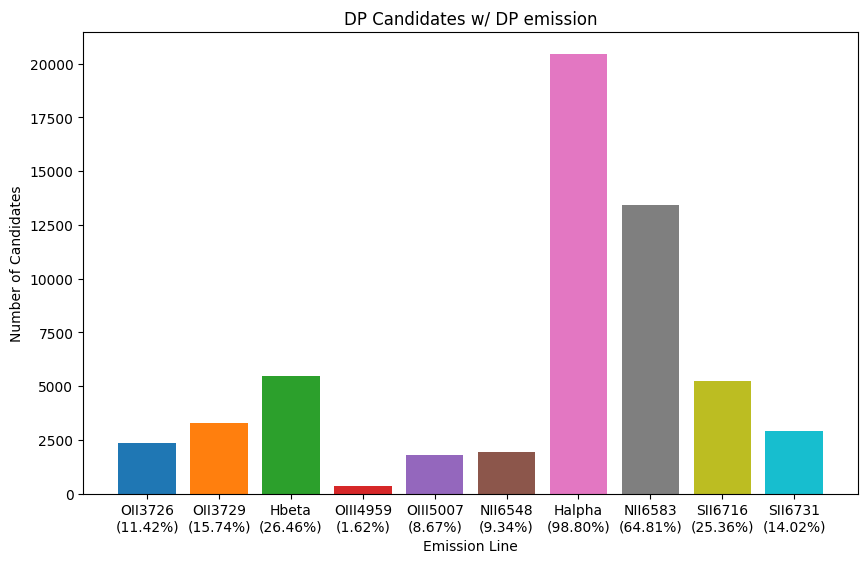

In [6]:
dp_cols = ['OII3726_dp', 'OII3729_dp',
            'Hbeta_dp',
            'OIII4959_dp', 'OIII5007_dp',
            'NII6548_dp', 'Halpha_dp', 'NII6583_dp', 
            'SII6716_dp', 'SII6731_dp']
plt.figure(figsize=(10, 6))
for col in dp_cols:
    dp_candidates[col] = dp_candidates[col].fillna(False)
    print(f"{col[:-3]}: {np.sum(dp_candidates[col])}")
    plt.bar(col[:-3]+f'\n({np.sum(dp_candidates[col]) / len(dp_candidates):.2%})', np.sum(dp_candidates[col]))
plt.xlabel("Emission Line")
plt.ylabel("Number of Candidates")
plt.title("DP Candidates w/ DP emission")
plt.savefig("./figures/Jan2/dp_candidates_emission.png")
plt.show()

In [7]:
dp_cols = ['OII3726_dp', 'OII3729_dp',
            'Hbeta_dp',
            'OIII4959_dp', 'OIII5007_dp',
            'NII6548_dp', 'Halpha_dp', 'NII6583_dp', 
            'SII6716_dp', 'SII6731_dp']
rank_cols = [col[:-3]+'_rank' for col in dp_cols]

dp_counts = dp_candidates[dp_cols].sum(axis=1)
dp_candidates['dp_count'] = dp_counts
display(dp_candidates[['TARGETID', 'dp_count']+dp_cols+rank_cols].head(5))

,TARGETID,dp_count,OII3726_dp,OII3729_dp,Hbeta_dp,OIII4959_dp,OIII5007_dp,NII6548_dp,Halpha_dp,NII6583_dp,...,OII3726_rank,OII3729_rank,Hbeta_rank,OIII4959_rank,OIII5007_rank,NII6548_rank,Halpha_rank,NII6583_rank,SII6716_rank,SII6731_rank
0,39627739380056564,2,False,False,False,False,False,False,True,True,...,-1,-1,-1,4,2,3,0,1,-1,-1
1,39627739380057506,1,False,False,False,False,False,False,True,False,...,-1,-1,-1,-1,-1,2,0,1,-1,-1
2,39627739380058467,4,False,True,False,False,False,False,True,True,...,3,1,-1,-1,-1,6,0,2,4,5
3,39627739380060210,2,False,False,False,False,False,False,True,True,...,-1,-1,2,-1,-1,4,0,1,3,5
4,39627739380061198,5,False,False,False,False,False,True,True,True,...,-1,-1,-1,-1,-1,3,0,1,2,4


In [8]:
dp_ = dp_candidates[dp_cols]
display(dp_.head(10))

,OII3726_dp,OII3729_dp,Hbeta_dp,OIII4959_dp,OIII5007_dp,NII6548_dp,Halpha_dp,NII6583_dp,SII6716_dp,SII6731_dp
0,False,False,False,False,False,False,True,True,False,False
1,False,False,False,False,False,False,True,False,False,False
2,False,True,False,False,False,False,True,True,True,False
3,False,False,False,False,False,False,True,True,False,False
4,False,False,False,False,False,True,True,True,True,True
5,False,False,False,False,False,False,True,False,False,False
6,False,False,False,False,False,False,True,False,False,False
7,False,False,False,False,False,False,True,True,False,False
8,False,False,False,False,False,False,True,True,False,False
9,False,False,False,False,False,False,True,False,False,False


In [9]:
rank_ = dp_candidates[rank_cols]
display(rank_.head(10))

,OII3726_rank,OII3729_rank,Hbeta_rank,OIII4959_rank,OIII5007_rank,NII6548_rank,Halpha_rank,NII6583_rank,SII6716_rank,SII6731_rank
0,-1,-1,-1,4,2,3,0,1,-1,-1
1,-1,-1,-1,-1,-1,2,0,1,-1,-1
2,3,1,-1,-1,-1,6,0,2,4,5
3,-1,-1,2,-1,-1,4,0,1,3,5
4,-1,-1,-1,-1,-1,3,0,1,2,4
5,-1,-1,-1,-1,-1,4,0,1,2,3
6,-1,-1,-1,-1,-1,2,0,1,-1,-1
7,-1,-1,2,-1,-1,3,0,1,-1,-1
8,-1,-1,1,-1,-1,4,0,2,3,5
9,-1,-1,-1,-1,-1,2,0,1,-1,-1


In [10]:
def get_actual_dp_count(row):
    """
    Calculates the number of consecutive double peaks starting from the brightest emission line.
    - Filters out lines with a rank of -1 (not detected).
    - Sorts the remaining emission lines by rank (brightness).
    - If the brightest line does not have a double peak, returns 0.
    - Otherwise, counts consecutive lines with double peaks starting from the brightest and returns the count.
    """
    # Create a list of (rank, dp_status) tuples for detected lines (rank != -1)
    line_info = []
    for rank_col, dp_col in zip(rank_cols, dp_cols):
        rank = row[rank_col]
        if rank != -1:
            line_info.append((rank, row[dp_col]))
    
    # If no lines were detected, there are no DPs to count.
    if not line_info:
        return 0
        
    # Sort by rank (the first element of the tuple)
    line_info.sort()

    # Check if the brightest line (first in the sorted list) has a double peak
    if not line_info[0][1]:
        return 0

    # Count consecutive double peaks from the brightest
    actual_dp_count = 0
    for rank, has_dp in line_info:
        if has_dp:
            actual_dp_count += 1
        else:
            # Stop counting when a line without a double peak is found
            break
            
    return actual_dp_count

# Apply the function to each row to create the new column
dp_candidates['actual_dp_count'] = dp_candidates.apply(get_actual_dp_count, axis=1)

# Display the head of the DataFrame with the new column
display(dp_candidates[['TARGETID', 'dp_count', 'actual_dp_count']].head(10))

,TARGETID,dp_count,actual_dp_count
0,39627739380056564,2,2
1,39627739380057506,1,1
2,39627739380058467,4,3
3,39627739380060210,2,2
4,39627739380061198,5,5
5,39627739380062010,1,1
6,39627739384251743,1,1
7,39627739384252917,2,2
8,39627739384253866,2,1
9,39627739384254171,1,1


In [11]:
dp_sample = dp_candidates[dp_candidates['actual_dp_count'] != False & (dp_candidates['actual_dp_count'] > 0)]
print(len(dp_sample))


20716


In [12]:
display(dp_sample[['TARGETID', 'dp_count', 'actual_dp_count']+dp_cols+rank_cols].head(10))

,TARGETID,dp_count,actual_dp_count,OII3726_dp,OII3729_dp,Hbeta_dp,OIII4959_dp,OIII5007_dp,NII6548_dp,Halpha_dp,...,OII3726_rank,OII3729_rank,Hbeta_rank,OIII4959_rank,OIII5007_rank,NII6548_rank,Halpha_rank,NII6583_rank,SII6716_rank,SII6731_rank
0,39627739380056564,2,2,False,False,False,False,False,False,True,...,-1,-1,-1,4,2,3,0,1,-1,-1
1,39627739380057506,1,1,False,False,False,False,False,False,True,...,-1,-1,-1,-1,-1,2,0,1,-1,-1
2,39627739380058467,4,3,False,True,False,False,False,False,True,...,3,1,-1,-1,-1,6,0,2,4,5
3,39627739380060210,2,2,False,False,False,False,False,False,True,...,-1,-1,2,-1,-1,4,0,1,3,5
4,39627739380061198,5,5,False,False,False,False,False,True,True,...,-1,-1,-1,-1,-1,3,0,1,2,4
5,39627739380062010,1,1,False,False,False,False,False,False,True,...,-1,-1,-1,-1,-1,4,0,1,2,3
6,39627739384251743,1,1,False,False,False,False,False,False,True,...,-1,-1,-1,-1,-1,2,0,1,-1,-1
7,39627739384252917,2,2,False,False,False,False,False,False,True,...,-1,-1,2,-1,-1,3,0,1,-1,-1
8,39627739384253866,2,1,False,False,False,False,False,False,True,...,-1,-1,1,-1,-1,4,0,2,3,5
9,39627739384254171,1,1,False,False,False,False,False,False,True,...,-1,-1,-1,-1,-1,2,0,1,-1,-1


In [13]:
counts = dp_sample['actual_dp_count'].value_counts().sort_index()
summary_df = counts.reindex(range(1, 11), fill_value=0).reset_index()
summary_df.columns = ['Number of actual double peaks', 'Number of DP Samples']
display(summary_df)

,Number of actual double peaks,Number of DP Samples
0,1,7886
1,2,7119
2,3,1983
3,4,1141
4,5,641
5,6,698
6,7,370
7,8,445
8,9,343
9,10,90


In [14]:
# with open('dp_samples_ids.txt', 'w+') as f:
#     for tid in dp_sample['TARGETID'].to_list():
#         f.write(f"{tid}\n")

In [15]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
color_data      = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_with_Flux.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

SPECTRA = Spectrum(spectra_data, color_data, cigale_data, fastspecfit, load_targetID=read_ids('dp_samples_ids.txt'))

In [16]:
display(SPECTRA.df[['TARGETID','LOGSFR', 'LOGM']].head(10))

,TARGETID,LOGSFR,LOGM
0,39627739380056564,0.941032,10.452706
1,39627739380057506,-0.880754,10.324258
2,39627739380058467,1.031611,10.402426
3,39627739380060210,0.039087,10.496312
4,39627739380061198,0.903058,9.514435
5,39627739380062010,0.143419,10.082529
6,39627739384251743,0.461850,9.779942
7,39627739384252917,-1.504955,10.019834
8,39627739384253866,1.160900,10.556721
9,39627739384254171,0.504521,10.280345


In [17]:
dp_sample['LOGSFR'] = dp_sample['TARGETID'].map(SPECTRA.df.set_index('TARGETID')['LOGSFR'])
dp_sample['LOGM'] = dp_sample['TARGETID'].map(SPECTRA.df.set_index('TARGETID')['LOGM'])
display(dp_sample[['TARGETID', 'LOGSFR', 'LOGM']].head(10))

,TARGETID,LOGSFR,LOGM
0,39627739380056564,0.941032,10.452706
1,39627739380057506,-0.880754,10.324258
2,39627739380058467,1.031611,10.402426
3,39627739380060210,0.039087,10.496312
4,39627739380061198,0.903058,9.514435
5,39627739380062010,0.143419,10.082529
6,39627739384251743,0.461850,9.779942
7,39627739384252917,-1.504955,10.019834
8,39627739384253866,1.160900,10.556721
9,39627739384254171,0.504521,10.280345


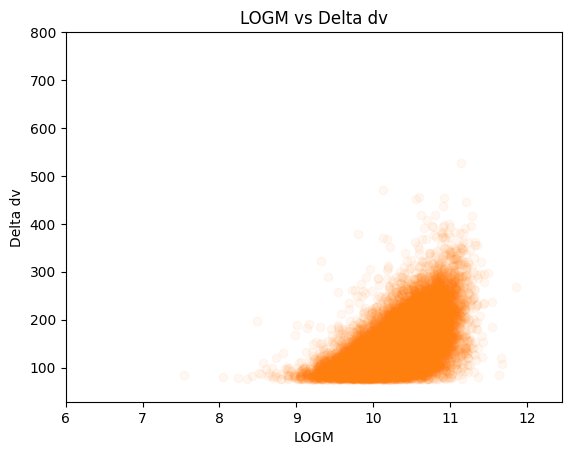

In [24]:
plt.scatter(dp_sample['LOGM'], dp_sample['delta_dv'], alpha=0.05, color='C1')
plt.xlabel('LOGM')
plt.ylabel('Delta dv')
plt.title('LOGM vs Delta dv')
plt.xlim(left=6)
plt.ylim(top=800)
plt.savefig('./figures/Jan2/LOGM_vs_Delta_dv_dp_samples.png')
plt.show()

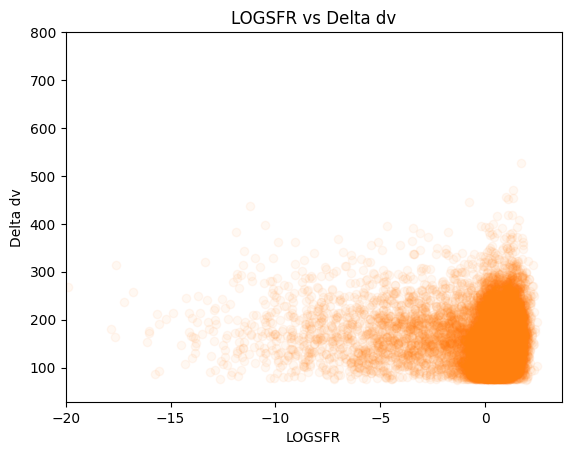

In [25]:
plt.scatter(dp_sample['LOGSFR'], dp_sample['delta_dv'], alpha=0.05, color='C1')
plt.xlabel('LOGSFR')
plt.ylabel('Delta dv')
plt.title('LOGSFR vs Delta dv')
plt.xlim(left=-20)
plt.ylim(top=800)
plt.savefig('./figures/Jan2/LOGSFR_vs_Delta_dv_dp_samples.png')
plt.show()